A notebook to generate plots from the post processed results of an across condition analysis

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import pickle
import re

from IPython.display import display
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from janelia_core.stats.regression import r_squared
from janelia_core.visualization.matrix_visualization import colorized_tbl

from probabilistic_model_synthesis.visualization import import_style
import_style()

In [3]:
# %matplotlib notebook

## Parameters go here 

In [4]:
# Top-level directory holding the results
base_dir = r'/nrs/ahrens/Luuk/DPMS_results/publication_results/gnldr/quantification'
# base_dir = r'/groups/fitzgerald/fitzgeraldlab/bishoplab/projects/probabilistic_model_synthsis/results/publication_results/gnldr/quantification'

# Name used for all files containing post-processed results
pp_file = r'pp_fit_results.pt'

# Specify the type of models we assess performance for - can be 'sp' or 'ip'
mdl_type = 'ip'

# Specify conditions we test on 
test_conds = ['omr_forward', 'omr_right', 'omr_left']

# Specify folder to save images in 
save_folder = r'/nrs/ahrens/Luuk/DPMS_results/publication_results/gnldr/quantification/imgs'



In [5]:
import os

if not os.path.isdir(save_folder):
    os.makedirs(save_folder)

## Load all results

In [6]:
discovered_train_conds = [cond.name for cond in Path(base_dir).iterdir()
                         if cond.is_dir() and cond.name.startswith('omr')]
# Canonical conceptual order: Forward, Right, Left.
# Support both naming conventions in result folders.
desired_train_aliases = [
    ['omr_forward', 'omr_f_ns'],
    ['omr_right', 'omr_r_ns'],
    ['omr_left', 'omr_l_ns'],
]
train_conds = []
for aliases in desired_train_aliases:
    match = next((name for name in aliases if name in discovered_train_conds), None)
    if match is None:
        raise ValueError(
            f'Missing train condition folder for aliases {aliases}. Found: {sorted(discovered_train_conds)}'
        )
    train_conds.append(match)

test_subjs = np.sort([int(re.search('.*_(\\d+)', subj.name)[1])
                      for subj in (Path(base_dir) / train_conds[0]).iterdir()
                      if re.match('.*subj', str(subj)) is not None])


In [7]:
FIT_TYPES = ['multi_cond', 'single_cond']

In [8]:
rs = dict()
for cond in train_conds:
    rs[cond] = dict()
    for subj in test_subjs:
        rs[cond][subj] = dict()
        for fit_type in FIT_TYPES:
            fit_type_dir = Path(base_dir) / cond / ('subj_' + str(subj)) / fit_type
            fit_type_file = fit_type_dir / pp_file
            
            load_kwargs = {'map_location': torch.device('cpu')}
            try:
                rs[cond][subj][fit_type] = torch.load(fit_type_file, weights_only=False, **load_kwargs)
            except TypeError:
                rs[cond][subj][fit_type] = torch.load(fit_type_file, **load_kwargs)
            
            # Print some diagonstic information 
            print('Results for subject ' + str(subj) + ', train condition: ' + cond + 
                  ', fit type: ' + fit_type + ' ***')
            print('Best CP Ind: ' + str(rs[cond][subj][fit_type][mdl_type]['early_stopping']['best_cp_ind']))
            
      

Results for subject 8, train condition: omr_f_ns, fit type: multi_cond ***
Best CP Ind: 1
Results for subject 8, train condition: omr_f_ns, fit type: single_cond ***
Best CP Ind: 1
Results for subject 9, train condition: omr_f_ns, fit type: multi_cond ***
Best CP Ind: 1
Results for subject 9, train condition: omr_f_ns, fit type: single_cond ***
Best CP Ind: 1
Results for subject 11, train condition: omr_f_ns, fit type: multi_cond ***
Best CP Ind: 1
Results for subject 11, train condition: omr_f_ns, fit type: single_cond ***
Best CP Ind: 1
Results for subject 8, train condition: omr_r_ns, fit type: multi_cond ***
Best CP Ind: 1
Results for subject 8, train condition: omr_r_ns, fit type: single_cond ***
Best CP Ind: 1
Results for subject 9, train condition: omr_r_ns, fit type: multi_cond ***
Best CP Ind: 1
Results for subject 9, train condition: omr_r_ns, fit type: single_cond ***
Best CP Ind: 1
Results for subject 11, train condition: omr_r_ns, fit type: multi_cond ***
Best CP Ind: 1
Re

## Now assess test performance 

In [9]:
subj_elbos = dict()
n_train = len(train_conds)
n_test = len(test_conds)
for subj in test_subjs:
    subj_elbos[subj] = {'multi_cond': pd.DataFrame(np.zeros([n_train, n_test]), index=train_conds, columns=test_conds), 
                        'single_cond': pd.DataFrame(np.zeros([n_train, n_test]), index=train_conds, columns=test_conds)}

In [10]:
for ts_i, test_cond in enumerate(test_conds):
    print('**** Test Condition: ' + test_cond + ' ****')
    for s_i, subj in enumerate(test_subjs):
        print('Subject: ' + str(subj))
        print('Single ELBO, Multi ELBO, Delta, Training Condition')
        for tr_i, train_cond in enumerate(train_conds):
            single_period_elbo_vls = rs[train_cond][subj]['single_cond'][mdl_type]['period_elbo_vls'][subj]
            multi_period_elbo_vls = rs[train_cond][subj]['multi_cond'][mdl_type]['period_elbo_vls'][subj]
            
            if single_period_elbo_vls[test_cond] is not None:
                single_elbo = single_period_elbo_vls[test_cond]['vl']['elbo'].item()/single_period_elbo_vls[test_cond]['n_smps']
                multi_elbo = multi_period_elbo_vls[test_cond]['vl']['elbo'].item()/multi_period_elbo_vls[test_cond]['n_smps']
                delta_elbo = multi_elbo - single_elbo
                print('{:.2E}'.format(single_elbo) + ', ' + '{:.2E}'.format(multi_elbo) + ', ' + 
                      '{:.2E}'.format(delta_elbo) + ', ' + train_cond)
                
                subj_elbos[subj]['single_cond'][test_cond][train_cond] = single_elbo
                subj_elbos[subj]['multi_cond'][test_cond][train_cond] = multi_elbo

**** Test Condition: omr_forward ****
Subject: 8
Single ELBO, Multi ELBO, Delta, Training Condition
-9.07E+04, -9.08E+04, -1.03E+02, omr_f_ns
-1.26E+05, -1.23E+05, 3.11E+03, omr_r_ns
-1.22E+05, -1.18E+05, 4.18E+03, omr_l_ns
Subject: 9
Single ELBO, Multi ELBO, Delta, Training Condition
-1.03E+05, -1.03E+05, -4.01E+02, omr_f_ns
-2.19E+05, -2.03E+05, 1.61E+04, omr_r_ns
-1.98E+05, -1.85E+05, 1.33E+04, omr_l_ns
Subject: 11
Single ELBO, Multi ELBO, Delta, Training Condition
-1.02E+05, -1.02E+05, 6.96E+02, omr_f_ns
-1.18E+05, -1.14E+05, 3.35E+03, omr_r_ns
-1.23E+05, -1.19E+05, 3.85E+03, omr_l_ns
**** Test Condition: omr_right ****
Subject: 8
Single ELBO, Multi ELBO, Delta, Training Condition
-1.30E+05, -1.28E+05, 2.15E+03, omr_f_ns
-8.89E+04, -8.92E+04, -2.80E+02, omr_r_ns
-1.51E+05, -1.34E+05, 1.74E+04, omr_l_ns
Subject: 9
Single ELBO, Multi ELBO, Delta, Training Condition
-1.22E+05, -1.18E+05, 3.77E+03, omr_f_ns
-8.82E+04, -8.85E+04, -2.49E+02, omr_r_ns
-1.50E+05, -1.37E+05, 1.36E+04, omr_l

In [11]:
label_map = {
    'omr_forward': 'F', 'omr_right': 'R', 'omr_left': 'L',
    'omr_f_ns': 'F', 'omr_r_ns': 'R', 'omr_l_ns': 'L',
}
ordered_labels = ['F', 'R', 'L']

for subj in test_subjs:
    for fit_type in ['multi_cond', 'single_cond']:
        df = subj_elbos[subj][fit_type].rename(index=label_map, columns=label_map)

        missing_rows = [lbl for lbl in ordered_labels if lbl not in df.index]
        missing_cols = [lbl for lbl in ordered_labels if lbl not in df.columns]
        if missing_rows or missing_cols:
            raise ValueError(
                f'Unexpected condition labels for subj={subj}, fit_type={fit_type}. '
                f'Rows={list(df.index)}, Cols={list(df.columns)}'
            )

        subj_elbos[subj][fit_type] = df.reindex(index=ordered_labels, columns=ordered_labels)

## Make tables of improvements in Normalized ELBO values when models are synthesized using data of different behaviors across fish

In [12]:
vl_range = 15000

In [13]:
cmap = matplotlib.colors.LinearSegmentedColormap.from_list(name='red_to_green', colors=[(0,  [0.0, 0.0, 1.0, 1.0]),
                                                               (.5, [0.0, 0.0, 0.0, 0.0]),
                                                               (1.0, [1.0, 0.0, 0.0, 1.0])], N=1024)

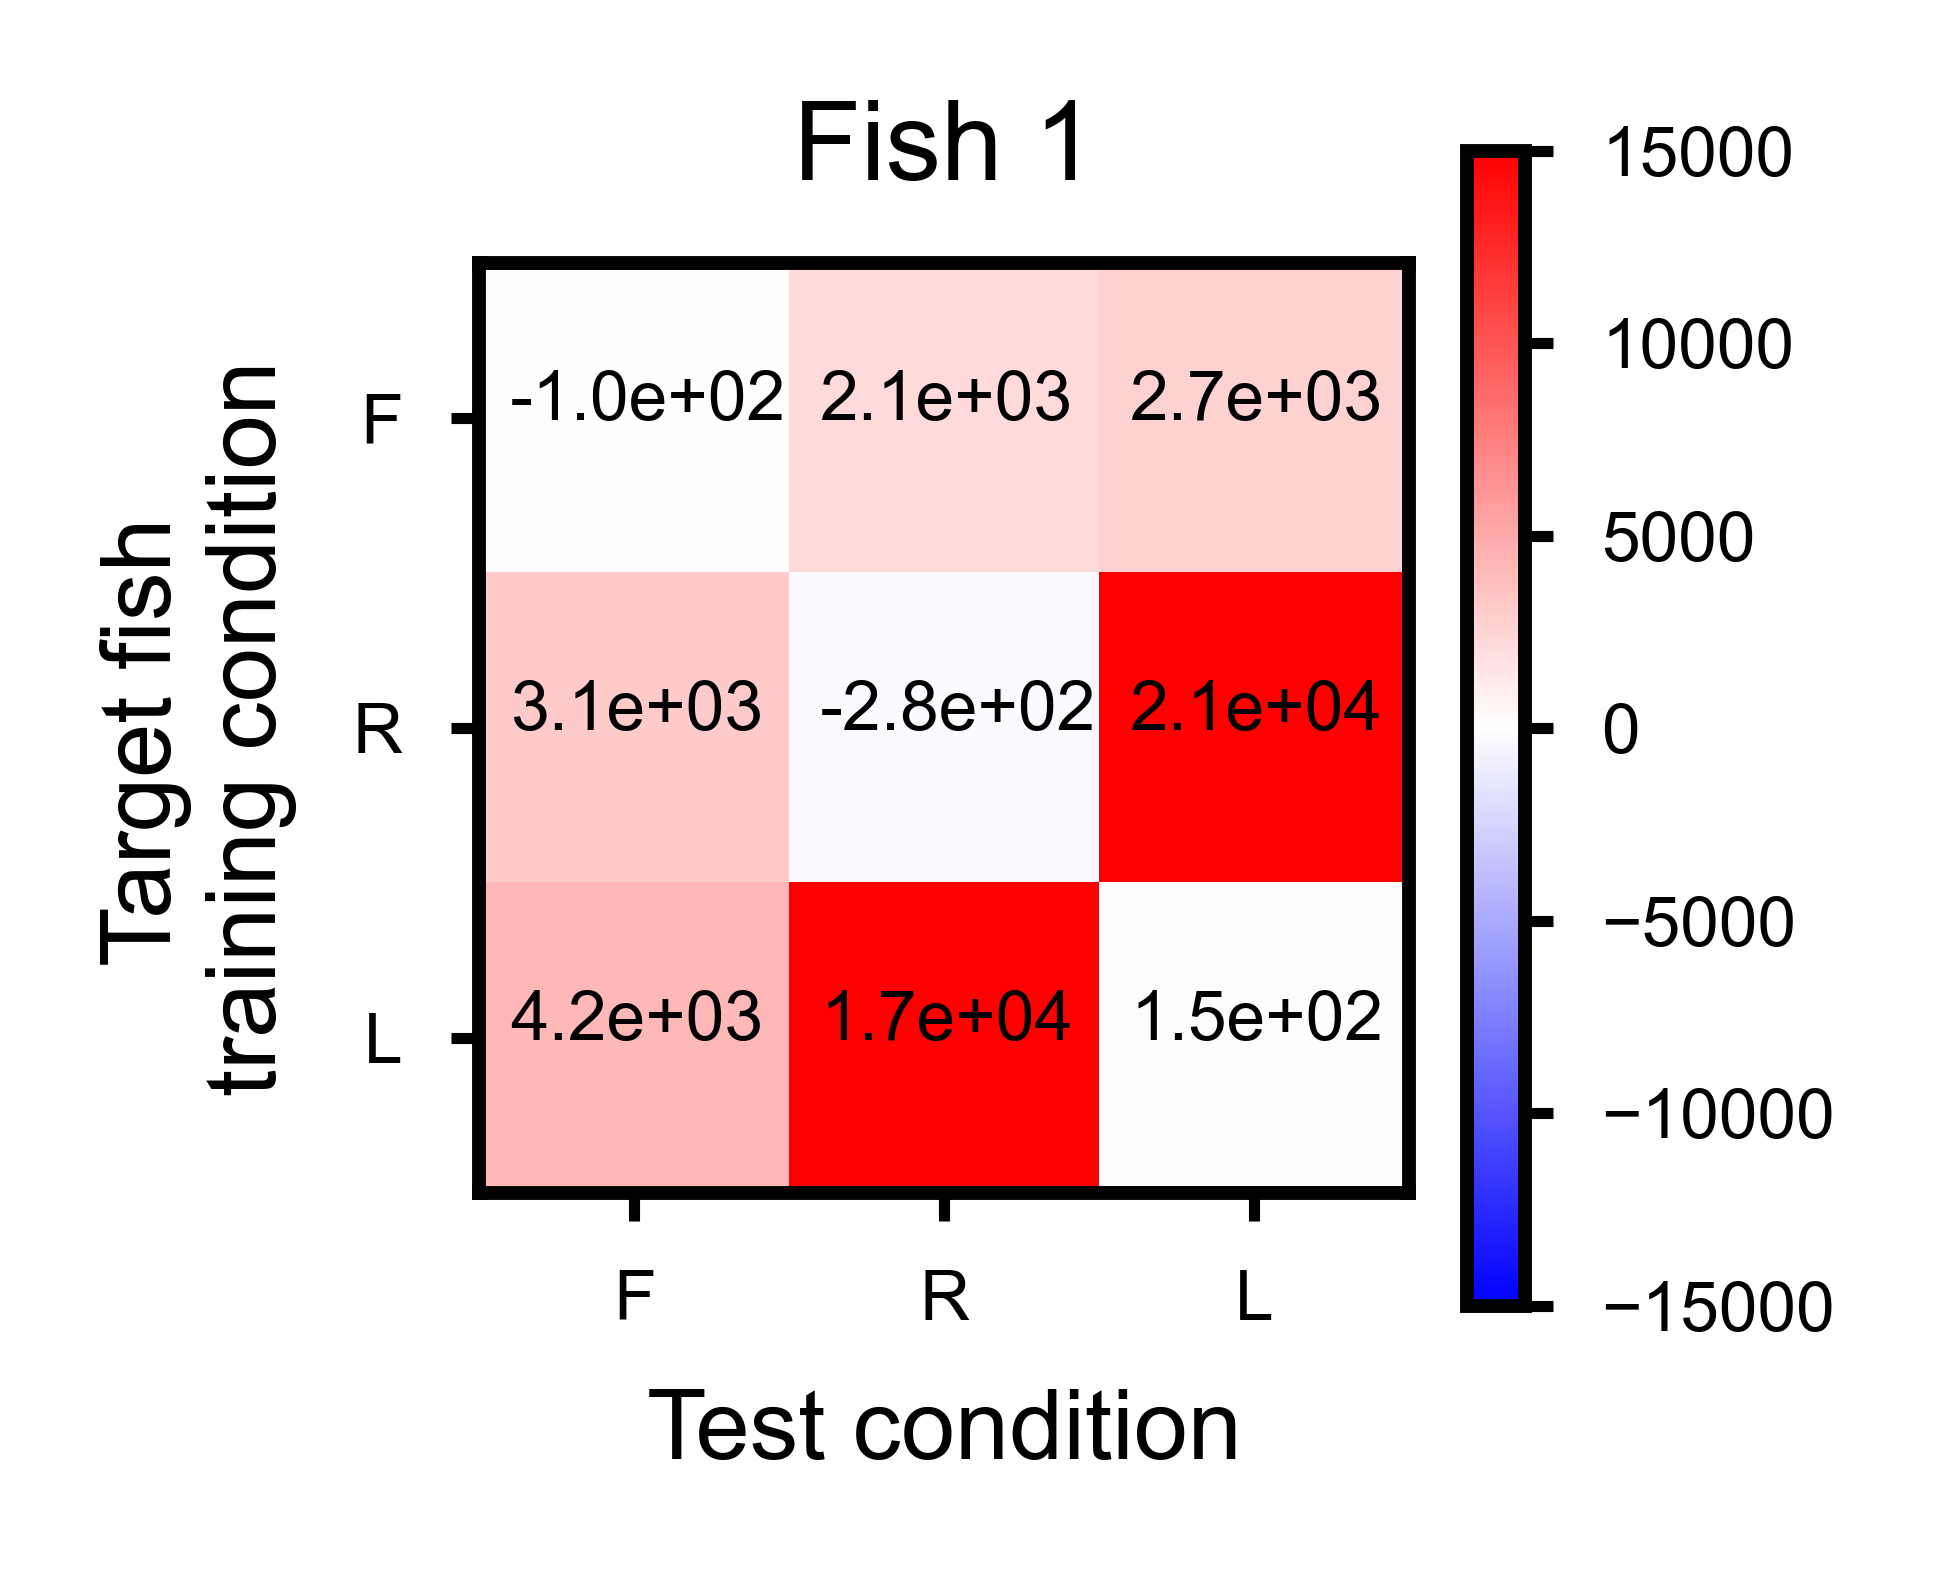

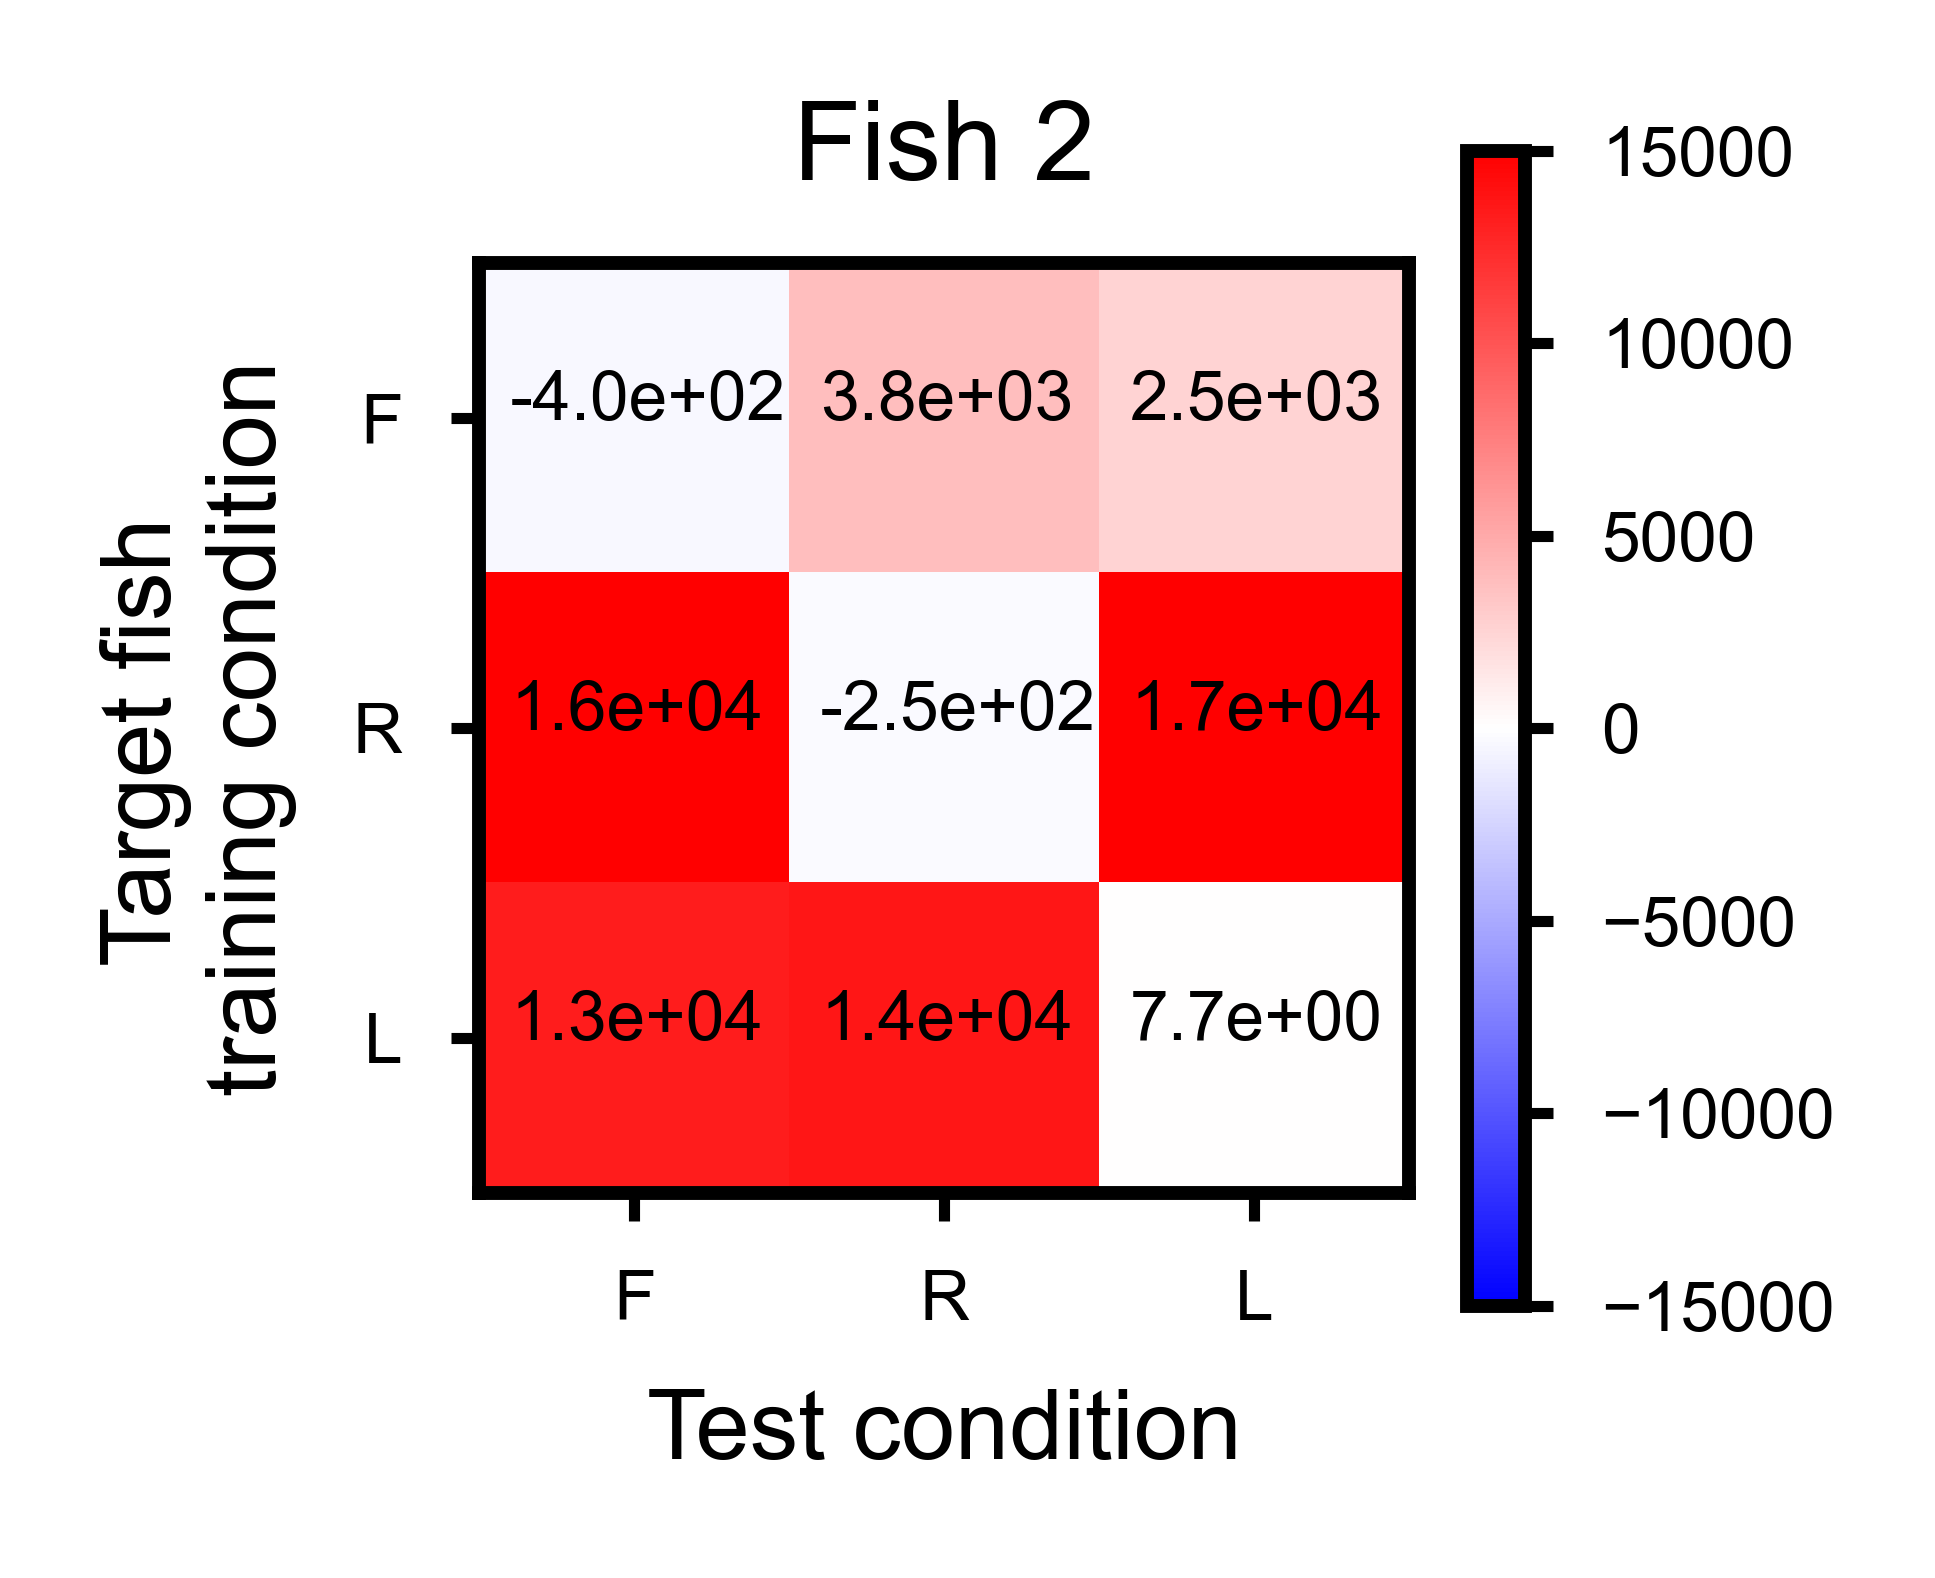

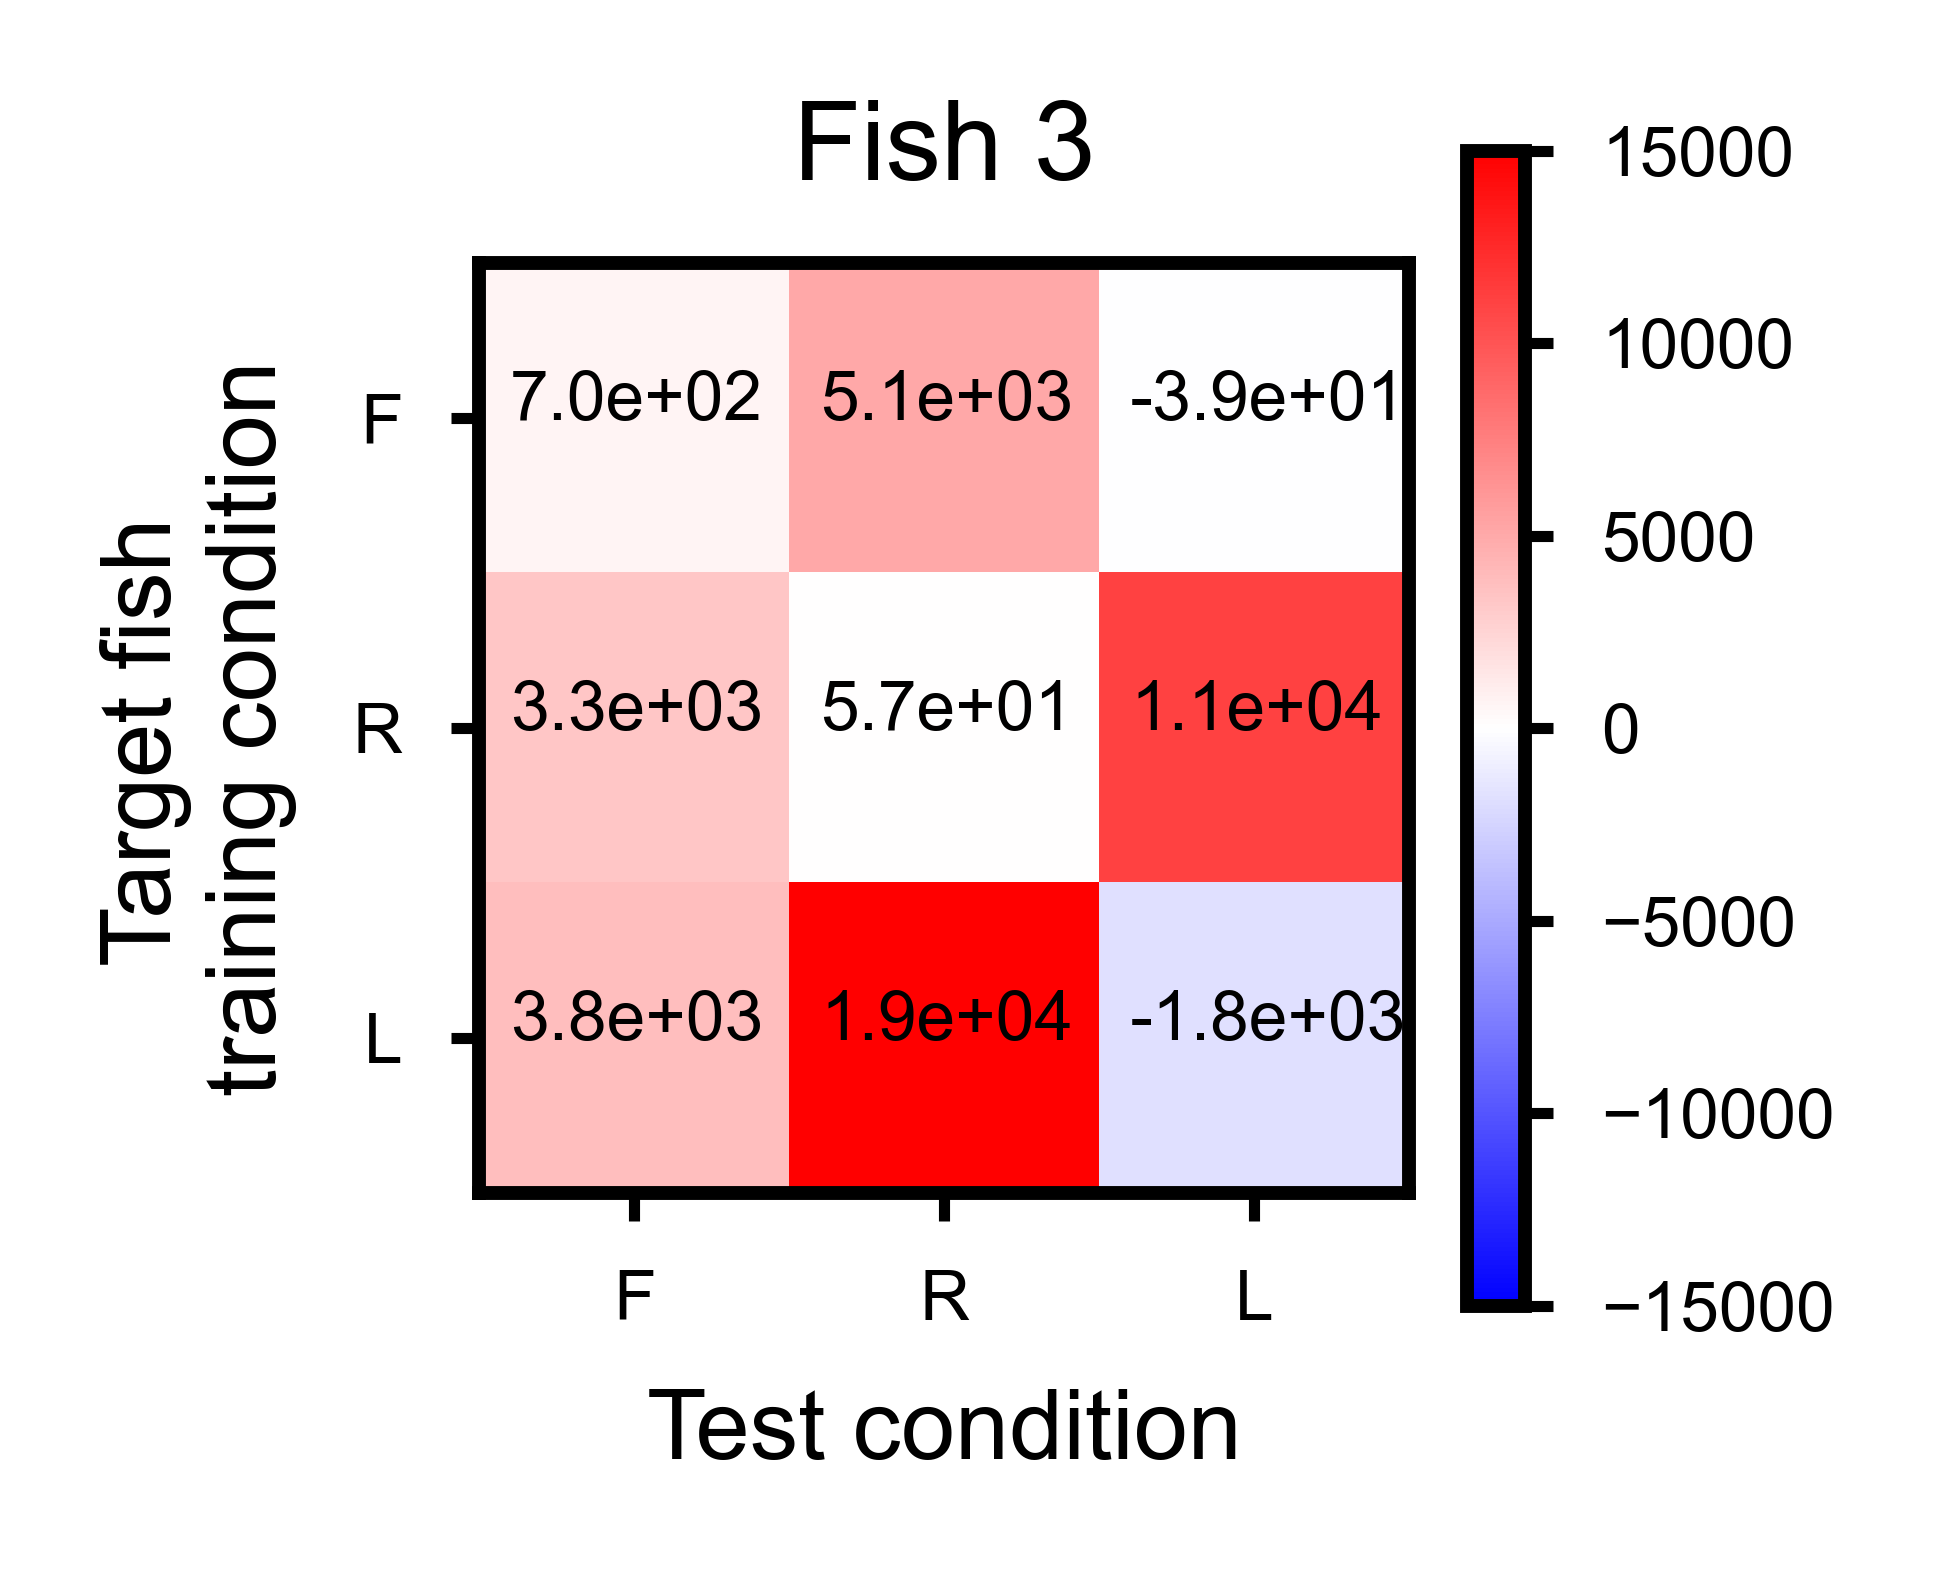

In [14]:
for subj_i, subj in enumerate(test_subjs):
    elbo_improvements = subj_elbos[subj]['multi_cond'] - subj_elbos[subj]['single_cond']  
    fig = plt.figure(figsize=(1.5, 1.5))
    ax = plt.subplot(1,1,1)
    colorized_tbl(tbl=elbo_improvements.to_numpy(), cmap='bwr', vmin=-vl_range, vmax=vl_range, 
                  dim_0_lbls=elbo_improvements.index.to_list(), 
                  dim_1_lbls=elbo_improvements.columns.to_list(), 
                  tbl_fontsize=5, label_fontsize=5,
                  ax=ax)
    ax.set_xlabel('Test condition')
    ax.set_ylabel('Target fish \ntraining condition')
    ax.set_title(f'Fish {subj_i+1}')
    
    save_file = 'elbo_improvements_subj_' + str(subj) + '.svg'
    save_path = Path(save_folder) / save_file
    plt.savefig(save_path, format='svg', dpi=500, bbox_inches="tight", pad_inches=0.05, transparent=True)

## Statistical testing (fish-level; recommended)

The legacy tests below concatenate many entries per fish and can overstate evidence by treating non-independent values as independent (pseudoreplication). Here we first collapse to one improvement value per fish, then test at the fish level with an exact paired sign-flip test (and Wilcoxon as a secondary reference).

In [15]:
from itertools import product
from scipy.stats import wilcoxon

# Improvement matrix per fish: multi-condition ELBO minus single-condition ELBO
elbo_improvement_tables = [subj_elbos[subj]['multi_cond'] - subj_elbos[subj]['single_cond'] for subj in test_subjs]
all_improvements = np.stack([tbl.to_numpy() for tbl in elbo_improvement_tables], axis=0)

n_fish, n_rows, n_cols = all_improvements.shape
if n_rows != n_cols:
    raise ValueError('Expected square condition matrices per fish.')

offdiag_mask = ~np.eye(n_rows, dtype=bool)

# One summary value per fish for each effect type
fish_delta_offd = all_improvements[:, offdiag_mask].mean(axis=1)
fish_delta_d = np.diagonal(all_improvements, axis1=1, axis2=2).mean(axis=1)
fish_delta_full = all_improvements.mean(axis=(1, 2))

def exact_sign_flip_test(deltas, alternative='greater'):
    deltas = np.asarray(deltas, dtype=float)
    deltas = deltas[~np.isnan(deltas)]
    n = deltas.size
    if n == 0:
        raise ValueError('No valid fish-level deltas available for testing.')

    signs = np.array(list(product([-1.0, 1.0], repeat=n)))
    null_stats = (signs * deltas).mean(axis=1)
    observed = deltas.mean()

    if alternative == 'greater':
        p_value = np.mean(null_stats >= observed)
    elif alternative == 'less':
        p_value = np.mean(null_stats <= observed)
    elif alternative == 'two-sided':
        p_value = np.mean(np.abs(null_stats) >= abs(observed))
    else:
        raise ValueError("alternative must be 'greater', 'less', or 'two-sided'")

    return observed, p_value, null_stats

def safe_wilcoxon(deltas, alternative='greater'):
    deltas = np.asarray(deltas, dtype=float)
    try:
        stat, p_value = wilcoxon(deltas, zero_method='wilcox', alternative=alternative, mode='exact')
    except ValueError:
        stat, p_value = np.nan, np.nan
    return stat, p_value

test_sets = {
    'off-diagonal': fish_delta_offd,
    'diagonal': fish_delta_d,
    'all cells': fish_delta_full,
}

print(f'Fish count used for testing: {n_fish}')
print('Alternative hypothesis: transfer improvement > 0')
print('')

for name, deltas in test_sets.items():
    observed, p_exact, _ = exact_sign_flip_test(deltas, alternative='greater')
    _, p_wilcoxon = safe_wilcoxon(deltas, alternative='greater')
    print(f'{name}:')
    print(f'  fish deltas = {np.array2string(deltas, precision=4)}')
    print(f'  mean delta = {observed:.4e}')
    print(f'  exact sign-flip p = {p_exact:.4f}')
    print(f'  wilcoxon p = {p_wilcoxon:.4f}')
    print('')

Fish count used for testing: 3
Alternative hypothesis: transfer improvement > 0

off-diagonal:
  fish deltas = [ 8389.3753 10986.0271  6996.2   ]
  mean delta = 8.7905e+03
  exact sign-flip p = 0.1250
  wilcoxon p = 0.1250

diagonal:
  fish deltas = [ -77.2943 -213.9739 -346.9892]
  mean delta = -2.1275e+02
  exact sign-flip p = 1.0000
  wilcoxon p = 1.0000

all cells:
  fish deltas = [5567.1521 7252.6934 4548.4703]
  mean delta = 5.7894e+03
  exact sign-flip p = 0.1250
  wilcoxon p = 0.1250



## Figure-ready SB vs DB visualizations

### SB vs DB paired points with axis break (diagonal vs off-diagonal)
Diagonal pairs (train=test) are shown in a left subplot and off-diagonal transfer pairs in a right subplot with a true axis break.

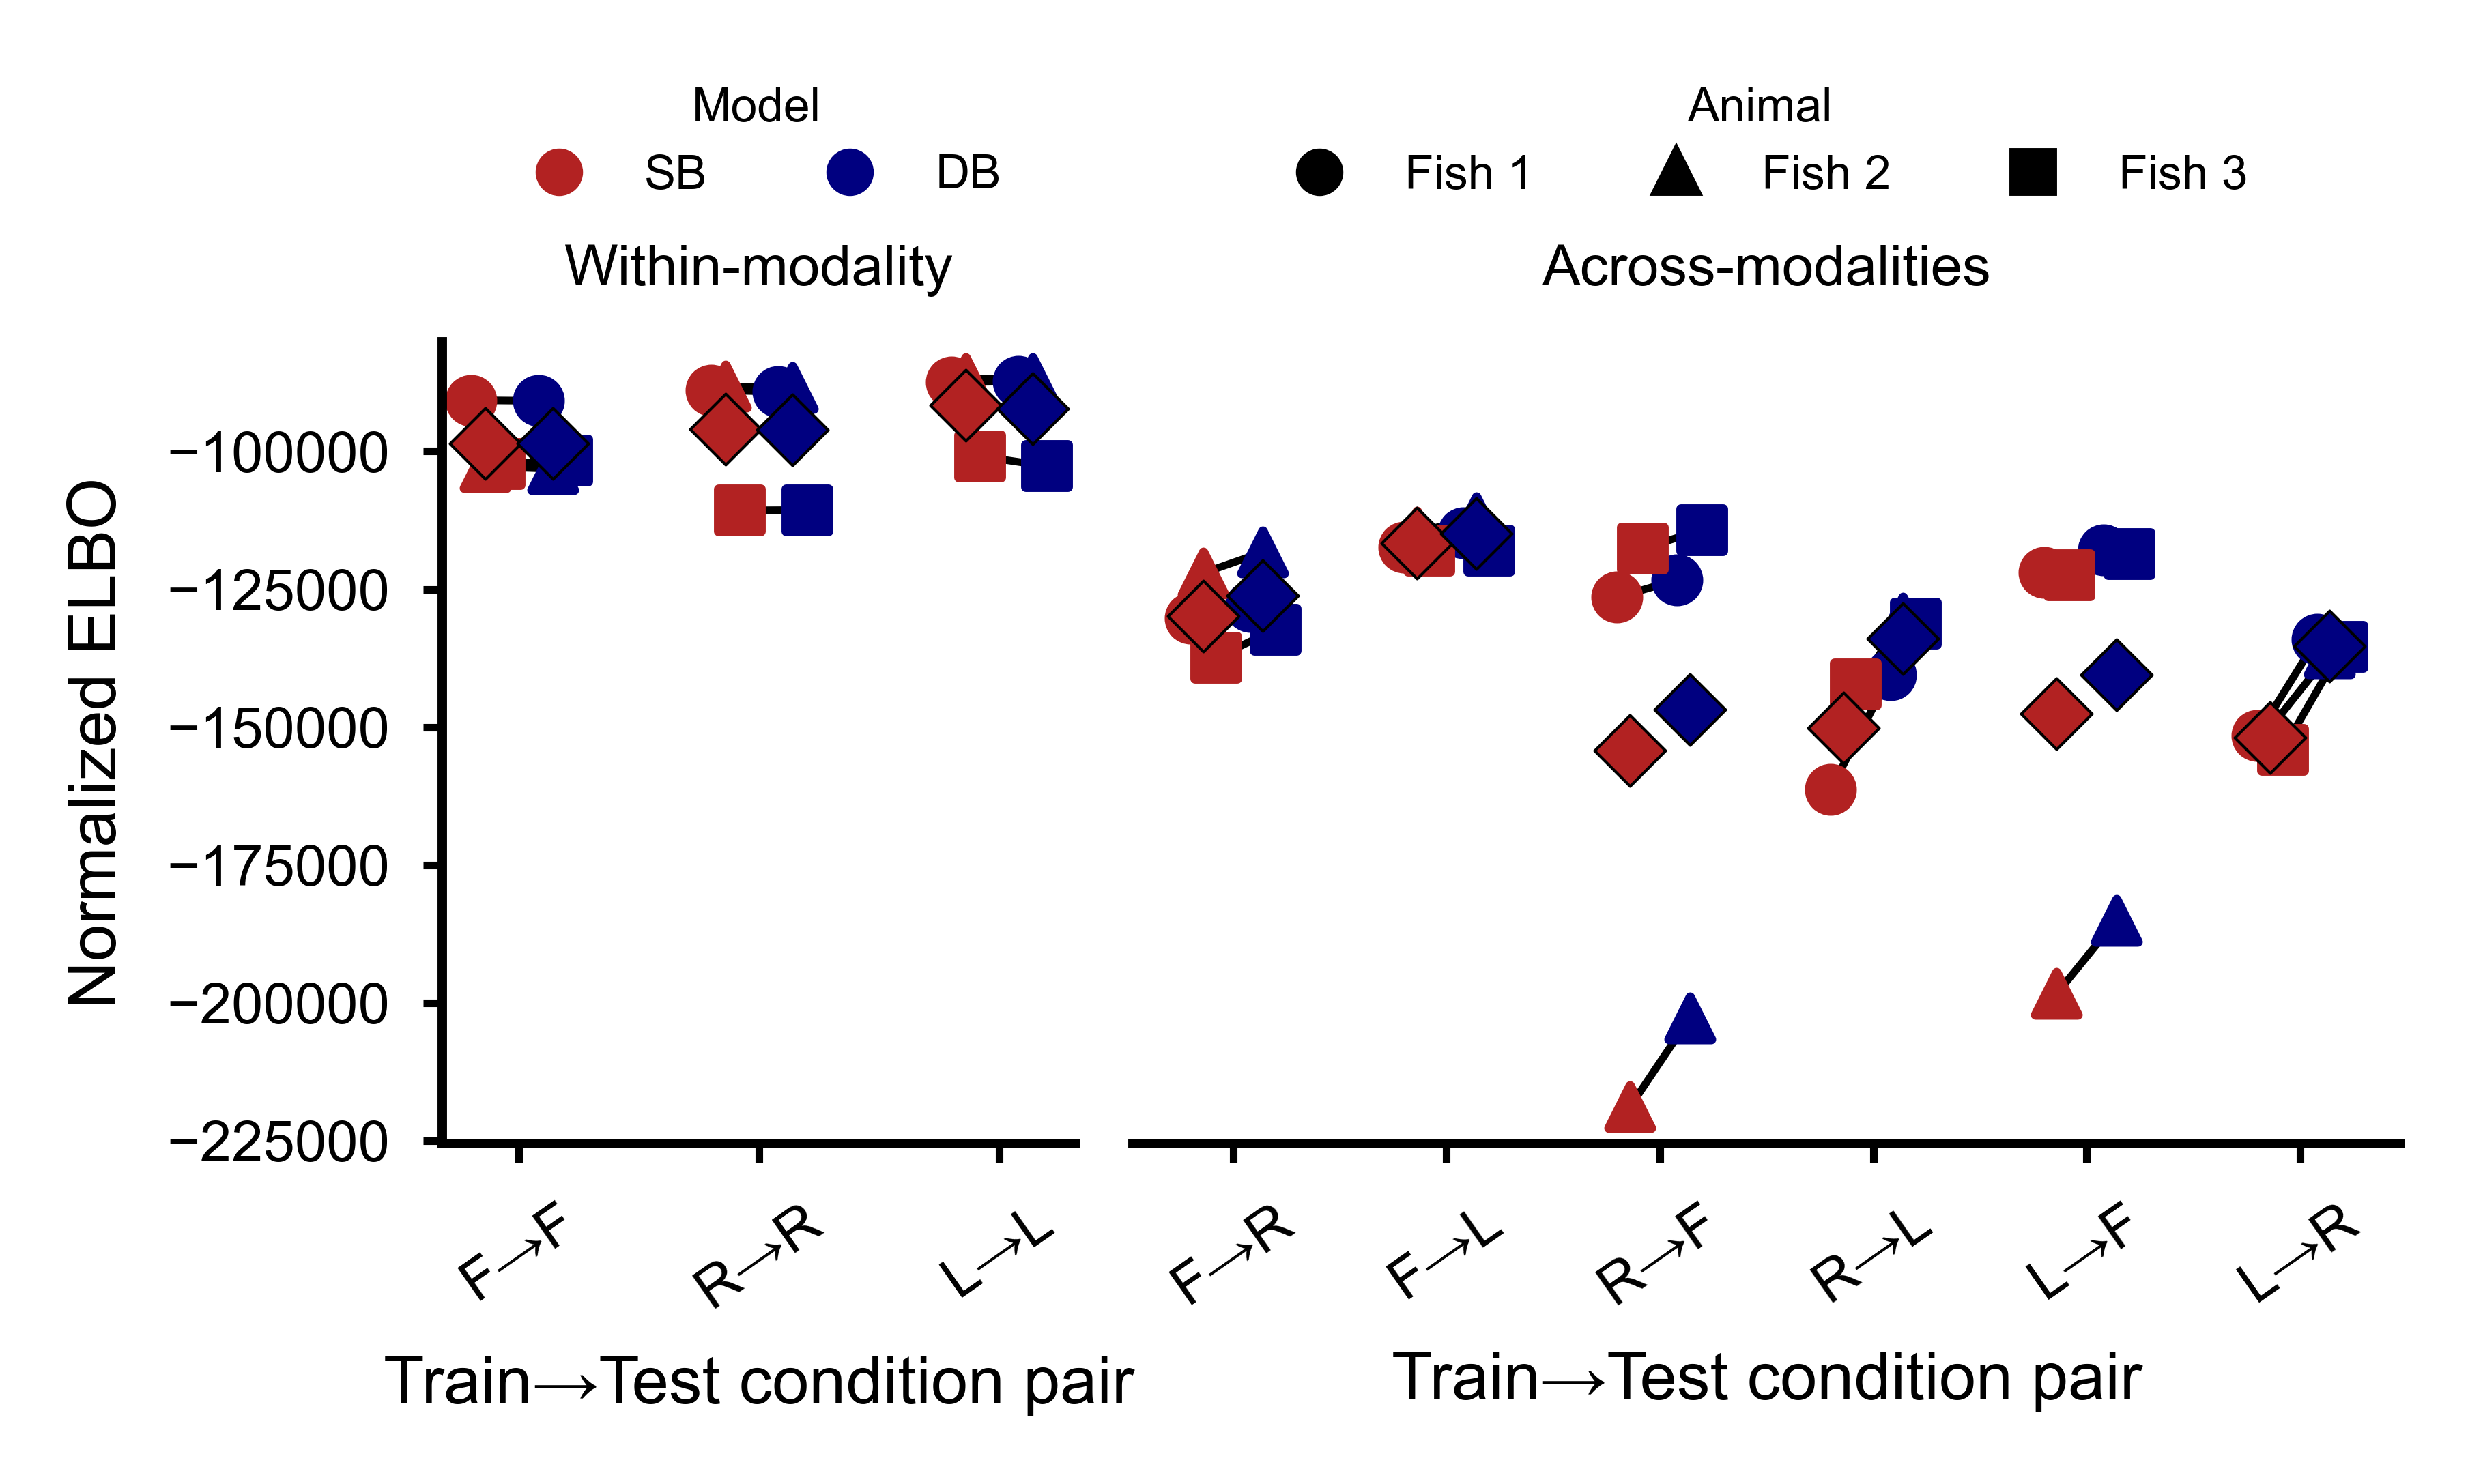

In [16]:
from matplotlib.lines import Line2D

fish_markers = ['o', '^', 's']
sb_color = 'firebrick'
db_color = 'navy'

label_rank = {
    'F': 0, 'R': 1, 'L': 2,
    'omr_forward': 0, 'omr_right': 1, 'omr_left': 2,
    'omr_f_ns': 0, 'omr_r_ns': 1, 'omr_l_ns': 2,
}

def pretty_label(lbl):
    mapping = {
        'omr_forward': 'F', 'omr_right': 'R', 'omr_left': 'L',
        'omr_f_ns': 'F', 'omr_r_ns': 'R', 'omr_l_ns': 'L',
    }
    return mapping.get(lbl, str(lbl))

def sort_labels(labels):
    return sorted(list(labels), key=lambda x: (label_rank.get(x, 999), str(x)))

sample_df = subj_elbos[test_subjs[0]]['single_cond']
train_labels = sort_labels(sample_df.index)
test_labels = sort_labels(sample_df.columns)

diag_pairs = [(tr, te) for tr in train_labels for te in test_labels if pretty_label(tr) == pretty_label(te)]
offdiag_pairs = [(tr, te) for tr in train_labels for te in test_labels if pretty_label(tr) != pretty_label(te)]

n_fish = len(test_subjs)
fish_offsets = np.linspace(-0.06, 0.06, n_fish)
sb_shift = -0.14
db_shift = 0.14

def collect_values(pairs):
    n_pairs = len(pairs)
    sb = np.zeros((n_fish, n_pairs), dtype=float)
    db = np.zeros((n_fish, n_pairs), dtype=float)
    for fi, subj in enumerate(test_subjs):
        df_sb = subj_elbos[subj]['single_cond']
        df_db = subj_elbos[subj]['multi_cond']
        for pi, (tr, te) in enumerate(pairs):
            sb[fi, pi] = df_sb.loc[tr, te]
            db[fi, pi] = df_db.loc[tr, te]
    return sb, db

def draw_group(ax, pairs, title):
    if len(pairs) == 0:
        ax.set_title(title, fontsize=6)
        ax.set_xticks([])
        ax.text(0.5, 0.5, 'No pairs', transform=ax.transAxes, ha='center', va='center', fontsize=5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        return

    sb, db = collect_values(pairs)
    pair_labels = [f"{pretty_label(tr)}→{pretty_label(te)}" for tr, te in pairs]
    pair_centers = np.arange(len(pairs), dtype=float)

    for pi in range(len(pairs)):
        x_center = pair_centers[pi]
        for fi in range(n_fish):
            mk = fish_markers[fi % len(fish_markers)]
            x_sb = x_center + sb_shift + fish_offsets[fi]
            x_db = x_center + db_shift + fish_offsets[fi]
            y_sb = sb[fi, pi]
            y_db = db[fi, pi]
            ax.plot([x_sb, x_db], [y_sb, y_db], color='k', linewidth=0.8, zorder=1)
            ax.scatter([x_sb], [y_sb], s=20, marker=mk, color=sb_color, zorder=2)
            ax.scatter([x_db], [y_db], s=20, marker=mk, color=db_color, zorder=2)

    mean_sb = sb.mean(axis=0)
    mean_db = db.mean(axis=0)
    ax.scatter(pair_centers + sb_shift, mean_sb, s=28, marker='D', color=sb_color, edgecolors='k', linewidths=0.3, zorder=3)
    ax.scatter(pair_centers + db_shift, mean_db, s=28, marker='D', color=db_color, edgecolors='k', linewidths=0.3, zorder=3)

    ax.set_xticks(pair_centers, labels=pair_labels)
    ax.tick_params(axis='x', labelrotation=35)
    ax.set_title(title, fontsize=6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig, axs = plt.subplots(
    1,
    2,
    figsize=(3.5, 1.8),
    sharey=True,
    constrained_layout=True,
    gridspec_kw={'width_ratios': [max(1, len(diag_pairs)), max(1, len(offdiag_pairs))]},
)

draw_group(axs[0], diag_pairs, 'Within-modality')
draw_group(axs[1], offdiag_pairs, 'Across-modalities')

axs[0].set_ylabel('Normalized ELBO')
axs[0].set_xlabel('Train→Test condition pair')
axs[1].set_xlabel('Train→Test condition pair')
axs[1].spines['left'].set_visible(False)
axs[1].tick_params(axis='y', left=False, labelleft=False)

model_handles = [
    Line2D([0], [0], marker='o', linestyle='None', color=sb_color, label='SB', markersize=4),
    Line2D([0], [0], marker='o', linestyle='None', color=db_color, label='DB', markersize=4),
]
fish_handles = [
    Line2D([0], [0], marker=fish_markers[i], linestyle='None', color='k', label=f'Fish {i+1}', markersize=4)
    for i in range(n_fish)
]

fig.legend(handles=model_handles, frameon=False, fontsize=5, loc='upper center', bbox_to_anchor=(0.30, 1.14), title='Model', title_fontsize=5, ncol=2)
fig.legend(handles=fish_handles, frameon=False, fontsize=5, loc='upper center', bbox_to_anchor=(0.72, 1.14), title='Animal', title_fontsize=5, ncol=n_fish)

save_path = Path(save_folder) / 'elbo_sb_db_paired_by_condition.svg'
plt.savefig(save_path, format='svg', dpi=500, bbox_inches='tight', pad_inches=0.05, transparent=True)


### DB vs SB identity scatter
Each point is one fish-condition observation. Points above the identity line indicate DB outperforming SB. Fish are shape-coded and condition pairs are color-coded.


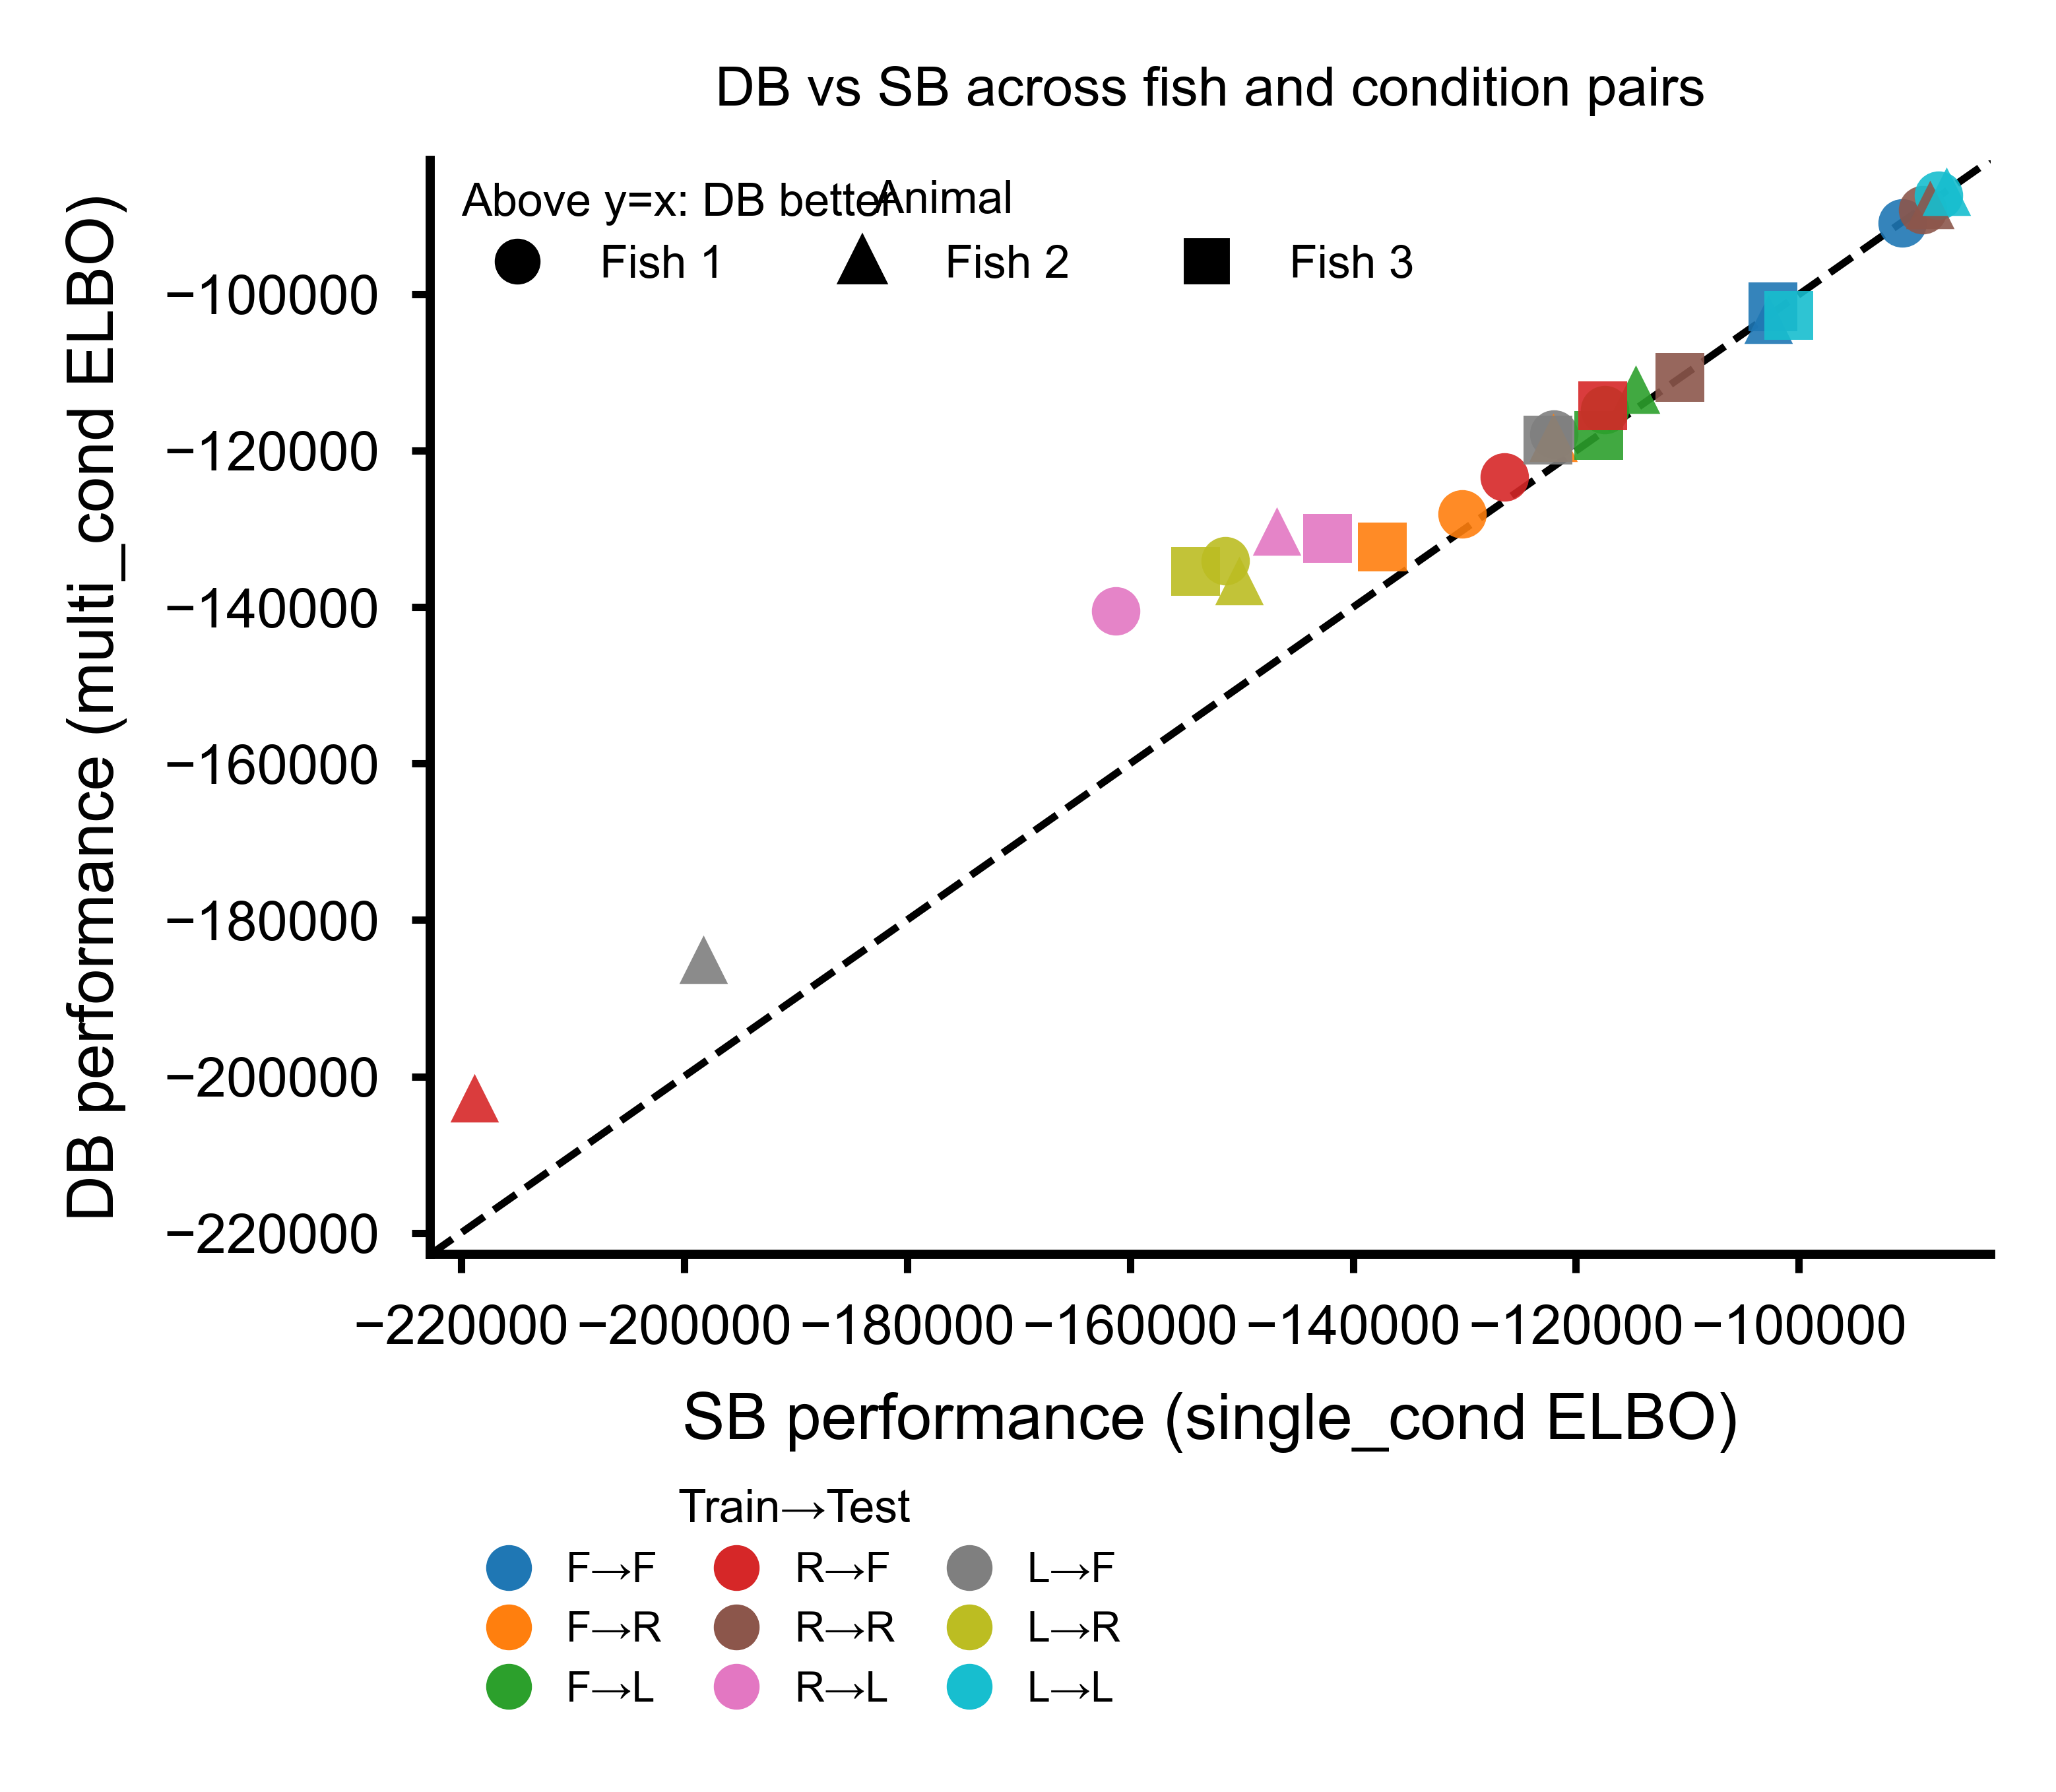

In [17]:
from matplotlib.lines import Line2D

fish_markers = ['o', '^', 's']

label_rank = {
    'F': 0, 'R': 1, 'L': 2,
    'omr_forward': 0, 'omr_right': 1, 'omr_left': 2,
    'omr_f_ns': 0, 'omr_r_ns': 1, 'omr_l_ns': 2,
}

def pretty_label(lbl):
    mapping = {
        'omr_forward': 'F', 'omr_right': 'R', 'omr_left': 'L',
        'omr_f_ns': 'F', 'omr_r_ns': 'R', 'omr_l_ns': 'L',
    }
    return mapping.get(lbl, str(lbl))

sample_df = subj_elbos[test_subjs[0]]['single_cond']
train_labels = sorted(list(sample_df.index), key=lambda x: (label_rank.get(x, 999), str(x)))
test_labels = sorted(list(sample_df.columns), key=lambda x: (label_rank.get(x, 999), str(x)))

condition_pairs = [(tr, te) for tr in train_labels for te in test_labels]
pair_labels = [f"{pretty_label(tr)}→{pretty_label(te)}" for tr, te in condition_pairs]
n_fish = len(test_subjs)
pair_colors = plt.cm.tab10(np.linspace(0, 1, len(condition_pairs)))

sb_vals = []
db_vals = []
meta = []
for fi, subj in enumerate(test_subjs):
    df_sb = subj_elbos[subj]['single_cond']
    df_db = subj_elbos[subj]['multi_cond']
    for pi, (tr, te) in enumerate(condition_pairs):
        sb_v = df_sb.loc[tr, te]
        db_v = df_db.loc[tr, te]
        sb_vals.append(sb_v)
        db_vals.append(db_v)
        meta.append((fi, pi))

sb_vals = np.asarray(sb_vals)
db_vals = np.asarray(db_vals)

fig, ax = plt.subplots(figsize=(3.0, 2.6), constrained_layout=True)
for (fi, pi), x, y in zip(meta, sb_vals, db_vals):
    ax.scatter(x, y, s=28, marker=fish_markers[fi % len(fish_markers)], color=pair_colors[pi], alpha=0.9, linewidths=0.0)

vmin = min(sb_vals.min(), db_vals.min())
vmax = max(sb_vals.max(), db_vals.max())
pad = 0.03 * (vmax - vmin if vmax > vmin else 1.0)
ax.plot([vmin - pad, vmax + pad], [vmin - pad, vmax + pad], 'k--', linewidth=0.8, zorder=0)
ax.set_xlim(vmin - pad, vmax + pad)
ax.set_ylim(vmin - pad, vmax + pad)

ax.set_xlabel('SB performance (single_cond ELBO)')
ax.set_ylabel('DB performance (multi_cond ELBO)')
ax.set_title('DB vs SB across fish and condition pairs', fontsize=6)
ax.text(0.02, 0.98, 'Above y=x: DB better', transform=ax.transAxes, va='top', fontsize=5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fish_handles = [
    Line2D([0], [0], marker=fish_markers[i], linestyle='None', color='k', label=f'Fish {i+1}', markersize=4)
    for i in range(n_fish)
]
pair_handles = [
    Line2D([0], [0], marker='o', linestyle='None', color=pair_colors[i], label=pair_labels[i], markersize=4)
    for i in range(len(condition_pairs))
]
leg1 = ax.legend(handles=fish_handles, frameon=False, fontsize=5, loc='upper left', bbox_to_anchor=(0.0, 1.02), title='Animal', title_fontsize=5, ncol=n_fish)
ax.add_artist(leg1)
ax.legend(handles=pair_handles, frameon=False, fontsize=4.5, loc='upper left', bbox_to_anchor=(0.0, -0.18), title='Train→Test', title_fontsize=5, ncol=3, columnspacing=0.8, handletextpad=0.4)

save_path = Path(save_folder) / 'elbo_sb_db_identity_scatter.svg'
plt.savefig(save_path, format='svg', dpi=500, bbox_inches='tight', pad_inches=0.05, transparent=True)


### Mean $\Delta$ELBO heatmap across fish\nHeatmap of mean improvement (DB - SB) across all animals for each train/test condition pair.

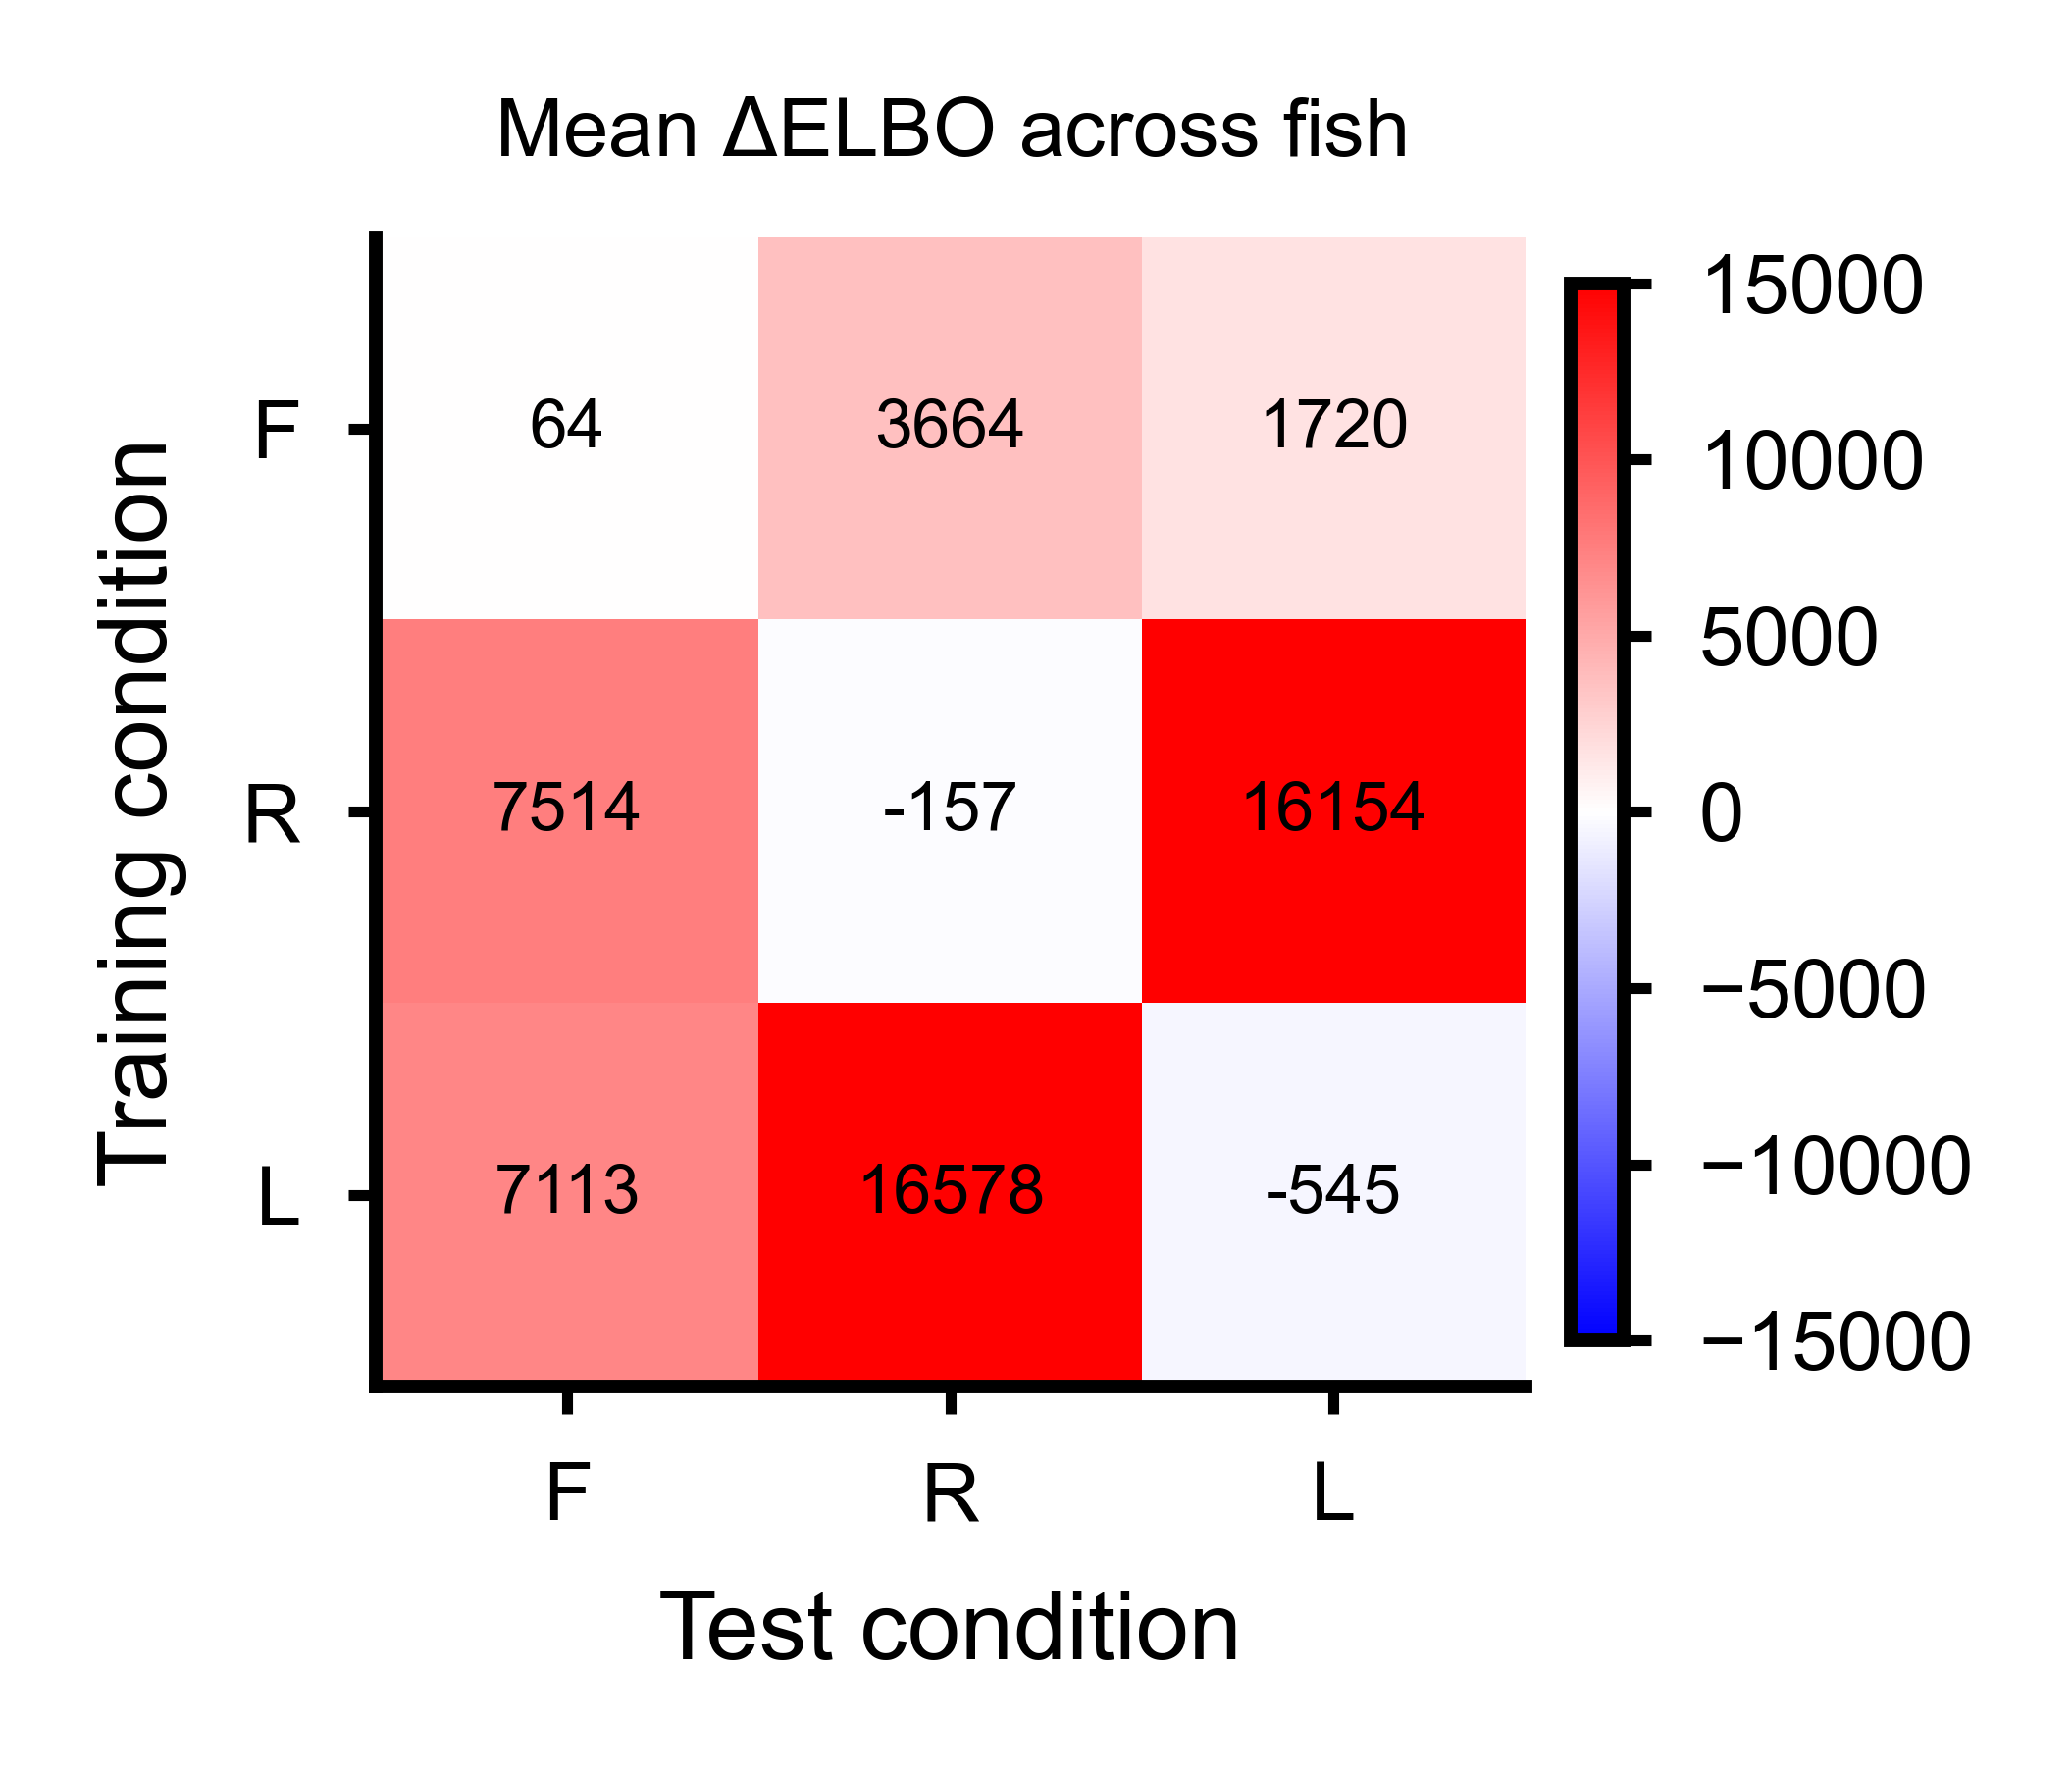

In [18]:
label_rank = {
    'F': 0, 'R': 1, 'L': 2,
    'omr_forward': 0, 'omr_right': 1, 'omr_left': 2,
    'omr_f_ns': 0, 'omr_r_ns': 1, 'omr_l_ns': 2,
}

def pretty_label(lbl):
    mapping = {
        'omr_forward': 'F', 'omr_right': 'R', 'omr_left': 'L',
        'omr_f_ns': 'F', 'omr_r_ns': 'R', 'omr_l_ns': 'L',
    }
    return mapping.get(lbl, str(lbl))

sample_df = subj_elbos[test_subjs[0]]['single_cond']
train_labels = sorted(list(sample_df.index), key=lambda x: (label_rank.get(x, 999), str(x)))
test_labels = sorted(list(sample_df.columns), key=lambda x: (label_rank.get(x, 999), str(x)))

all_improvements = []
for subj in test_subjs:
    df_delta = subj_elbos[subj]['multi_cond'] - subj_elbos[subj]['single_cond']
    df_delta = df_delta.reindex(index=train_labels, columns=test_labels)
    all_improvements.append(df_delta.to_numpy())
all_improvements = np.stack(all_improvements, axis=0)

mean_improvement = np.mean(all_improvements, axis=0)

fig, ax = plt.subplots(figsize=(2.0, 1.9), constrained_layout=True)
im = ax.imshow(mean_improvement, cmap='bwr', vmin=-vl_range, vmax=vl_range)
ax.set_xticks(np.arange(len(test_labels)), labels=[pretty_label(x) for x in test_labels])
ax.set_yticks(np.arange(len(train_labels)), labels=[pretty_label(x) for x in train_labels])
ax.set_xlabel('Test condition')
ax.set_ylabel('Training condition')
ax.set_title('Mean $\Delta$ELBO across fish', fontsize=6)

for r in range(mean_improvement.shape[0]):
    for c in range(mean_improvement.shape[1]):
        ax.text(c, r, f'{mean_improvement[r, c]:.0f}', ha='center', va='center', fontsize=5, color='black')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

save_path = Path(save_folder) / 'elbo_improvements_mean_across_fish_heatmap.svg'
plt.savefig(save_path, format='svg', dpi=500, bbox_inches='tight', pad_inches=0.05, transparent=True)


### Count of fish with positive $\Delta$ELBO\nHeatmap showing, for each train/test cell, how many animals improved (DB - SB > 0).

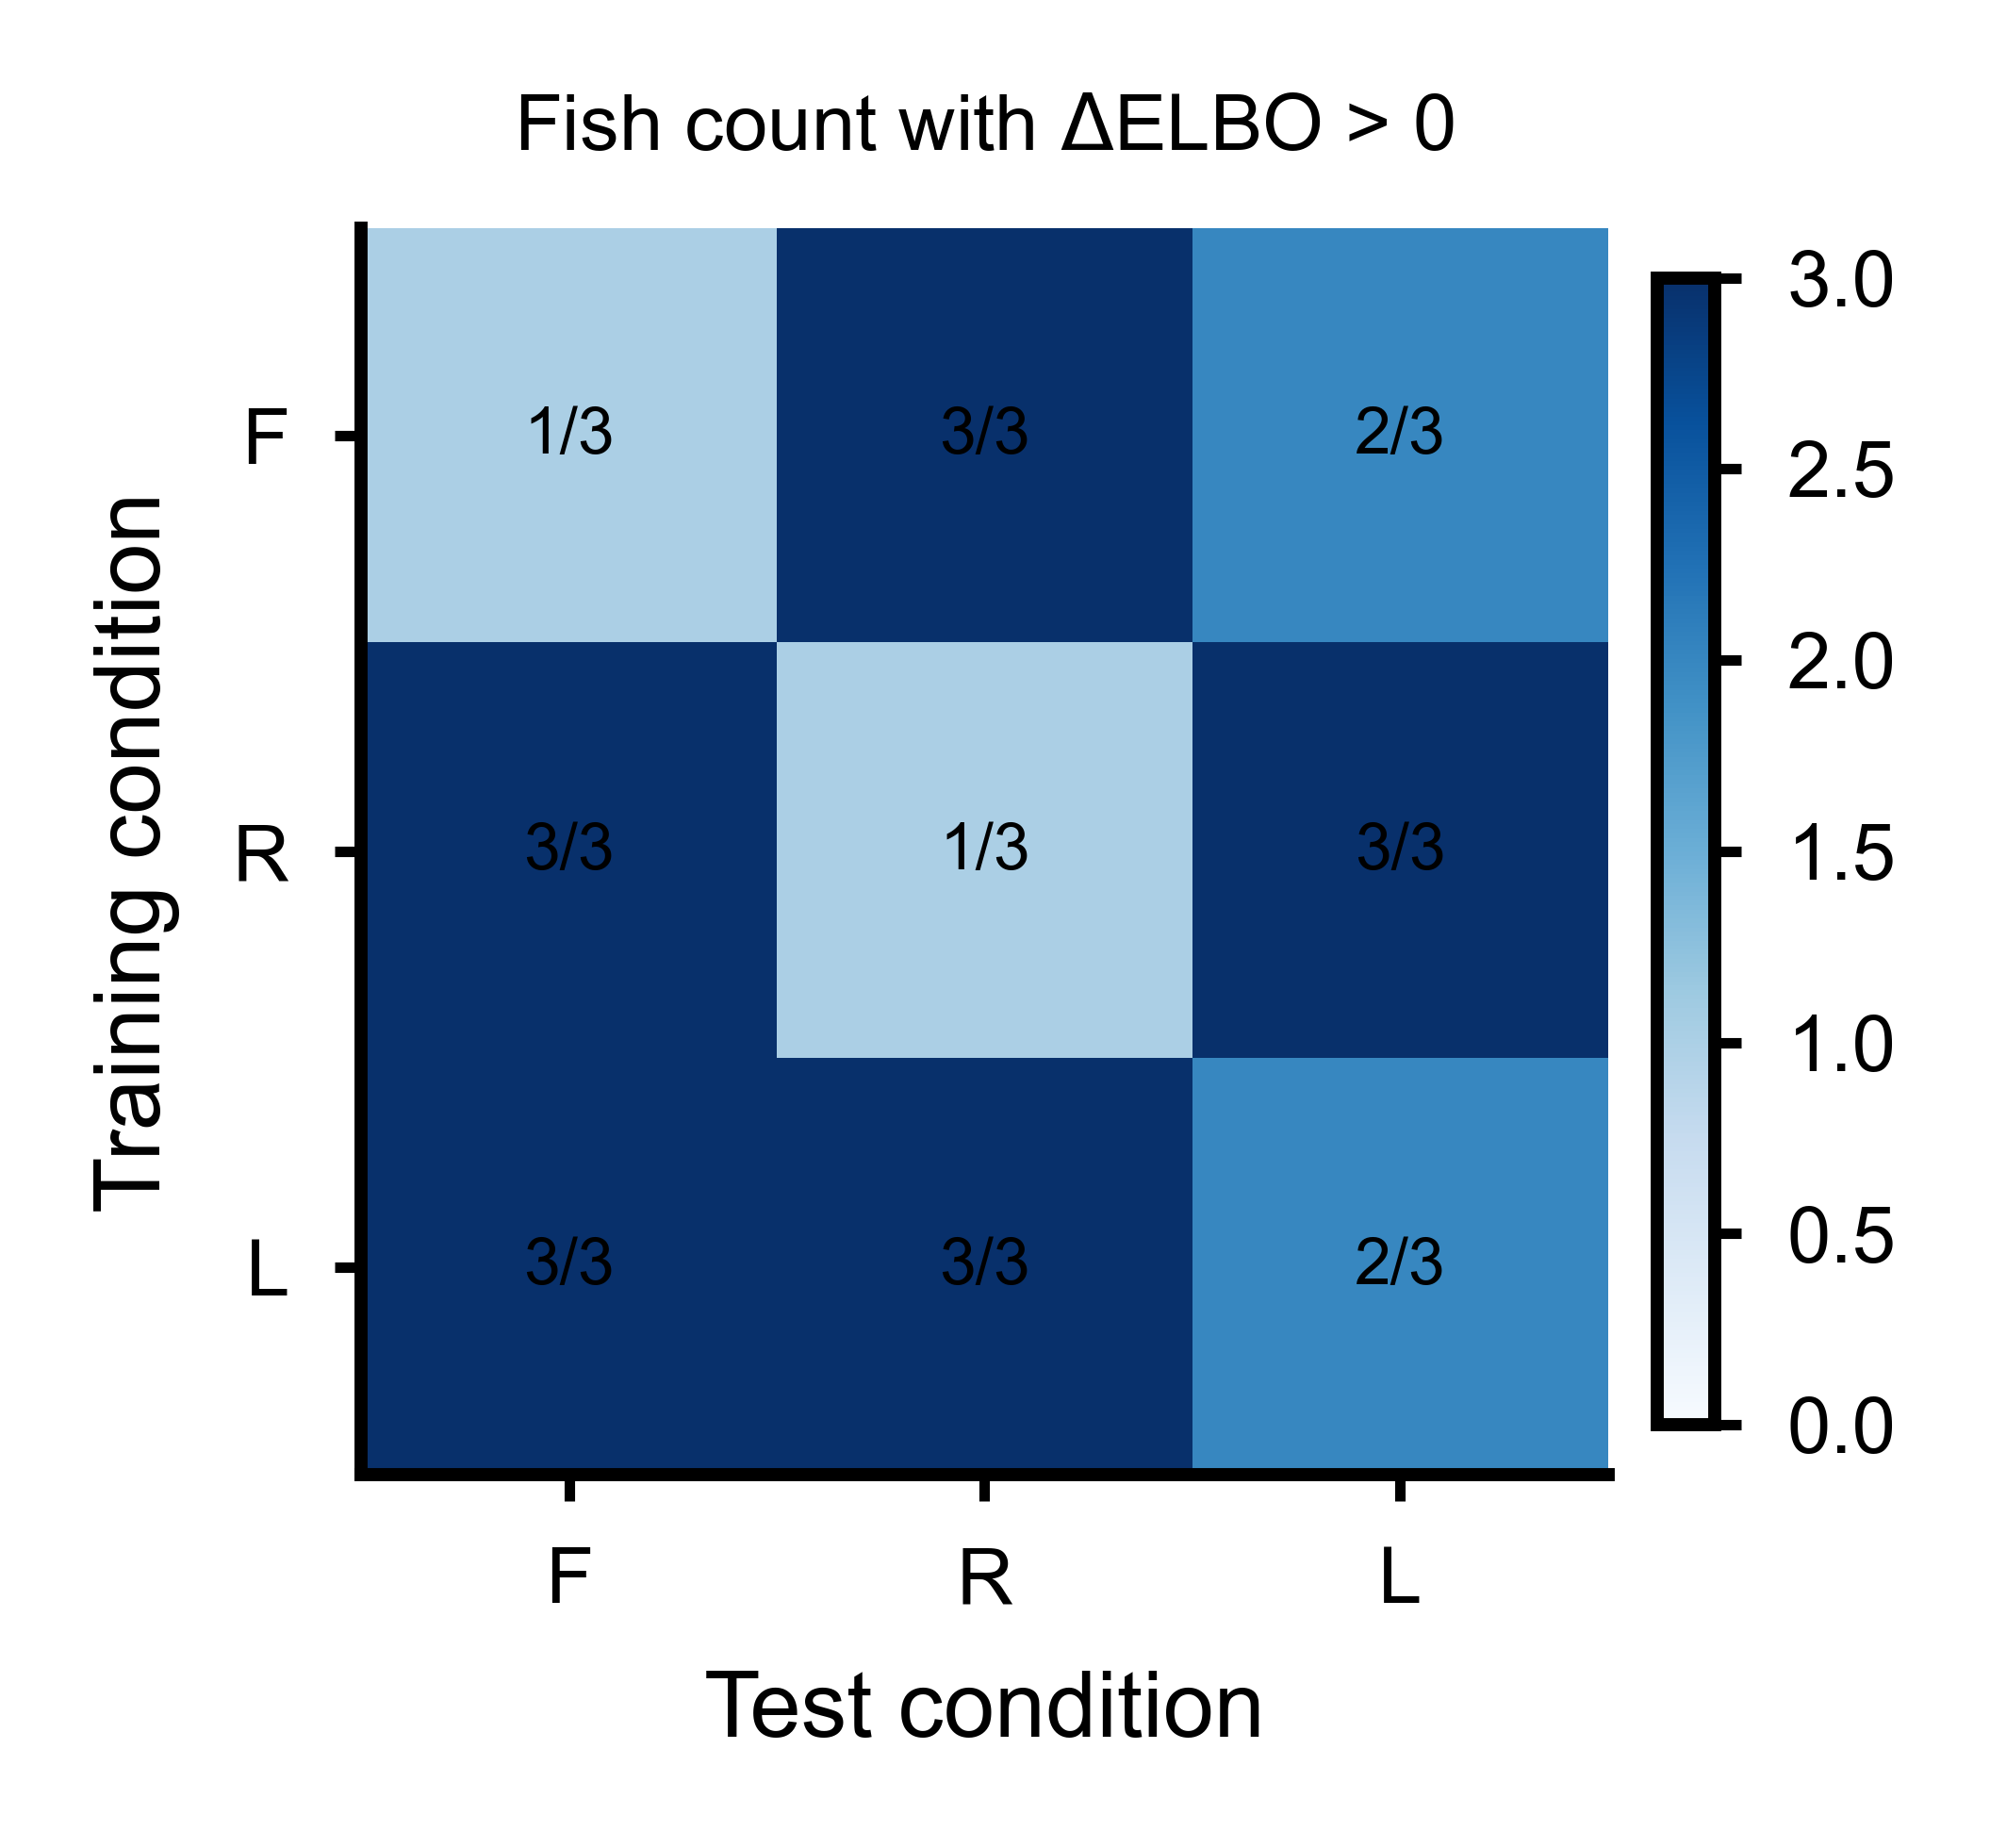

In [19]:
if 'all_improvements' not in globals() or 'train_labels' not in globals() or 'test_labels' not in globals():
    label_rank = {
        'F': 0, 'R': 1, 'L': 2,
        'omr_forward': 0, 'omr_right': 1, 'omr_left': 2,
        'omr_f_ns': 0, 'omr_r_ns': 1, 'omr_l_ns': 2,
    }

    def pretty_label(lbl):
        mapping = {
            'omr_forward': 'F', 'omr_right': 'R', 'omr_left': 'L',
            'omr_f_ns': 'F', 'omr_r_ns': 'R', 'omr_l_ns': 'L',
        }
        return mapping.get(lbl, str(lbl))

    sample_df = subj_elbos[test_subjs[0]]['single_cond']
    train_labels = sorted(list(sample_df.index), key=lambda x: (label_rank.get(x, 999), str(x)))
    test_labels = sorted(list(sample_df.columns), key=lambda x: (label_rank.get(x, 999), str(x)))

    all_improvements = []
    for subj in test_subjs:
        df_delta = subj_elbos[subj]['multi_cond'] - subj_elbos[subj]['single_cond']
        df_delta = df_delta.reindex(index=train_labels, columns=test_labels)
        all_improvements.append(df_delta.to_numpy())
    all_improvements = np.stack(all_improvements, axis=0)

n_fish = len(test_subjs)
positive_counts = np.sum(all_improvements > 0, axis=0)

fig, ax = plt.subplots(figsize=(2.0, 1.9), constrained_layout=True)
im = ax.imshow(positive_counts, cmap='Blues', vmin=0, vmax=n_fish)
ax.set_xticks(np.arange(len(test_labels)), labels=[pretty_label(x) for x in test_labels])
ax.set_yticks(np.arange(len(train_labels)), labels=[pretty_label(x) for x in train_labels])
ax.set_xlabel('Test condition')
ax.set_ylabel('Training condition')
ax.set_title('Fish count with $\Delta$ELBO > 0', fontsize=6)

for r in range(positive_counts.shape[0]):
    for c in range(positive_counts.shape[1]):
        ax.text(c, r, f'{int(positive_counts[r, c])}/{n_fish}', ha='center', va='center', fontsize=5, color='black')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

save_path = Path(save_folder) / 'elbo_improvements_positive_count_heatmap.svg'
plt.savefig(save_path, format='svg', dpi=500, bbox_inches='tight', pad_inches=0.05, transparent=True)


## Statistical testing (legacy; pseudoreplication-based)

In [20]:
# Create matrix with all animals
multi_cond_elbos = np.stack([subj_elbos[subj]['multi_cond'].to_numpy() for subj in test_subjs])
single_cond_elbos = np.stack([subj_elbos[subj]['single_cond'].to_numpy() for subj in test_subjs])

# Get values for each type (off-diagonal, diagonal and for all conditions)
# For each, we average across the columns, leaving out the diagonal value, as each column has the same data

### Off-diagonal
multi_cond_vals_offd = np.concatenate([(elbos.sum(axis=0) - np.diag(elbos)) / (elbos.shape[0] - 1) for elbos in multi_cond_elbos])
single_cond_vals_offd = np.concatenate([(elbos.sum(axis=0) - np.diag(elbos)) / (elbos.shape[0] - 1) for elbos in single_cond_elbos])

### Diagonal
multi_cond_vals_d = np.concatenate([np.diag(elbos) for elbos in multi_cond_elbos])
single_cond_vals_d = np.concatenate([np.diag(elbos) for elbos in single_cond_elbos])

### All
multi_cond_vals_full = np.concatenate([np.mean(elbos, axis=0) for elbos in multi_cond_elbos])
single_cond_vals_full = np.concatenate([np.mean(elbos, axis=0) for elbos in single_cond_elbos])

### Wilcoxon Signed-Rank Test (legacy)

In [21]:
from scipy.stats import wilcoxon

### Off-diagonal
statistic_offd, p_value_offd = wilcoxon(multi_cond_vals_offd, single_cond_vals_offd, alternative='two-sided')
print(f'p value off-diagonal: {p_value_offd:.2e}')

### Diagonal
statistic_d, p_value_d = wilcoxon(multi_cond_vals_d, single_cond_vals_d, alternative='two-sided')
print(f'p value diagonal: {p_value_d:.2e}')

### All
statistic_full, p_value_full = wilcoxon(multi_cond_vals_full, single_cond_vals_full, alternative='two-sided')
print(f'p value full: {p_value_full:.2e}')

p value off-diagonal: 3.91e-03
p value diagonal: 4.26e-01
p value full: 3.91e-03


### Permutation Test (legacy)

In [22]:
def paired_permutation_test(db_vals, sb_vals, n_permutations=10000, alternative='greater', random_state=None):
    """
    Performs a paired permutation test (sign flipping) between db and sb values.
    
    Args:
        db_vals: np.ndarray, shape (n,) ﷿﷿﷿ values under db condition
        sb_vals: np.ndarray, shape (n,) ﷿﷿﷿ values under sb condition
        n_permutations: int ﷿﷿﷿ number of permutations
        alternative: str ﷿﷿﷿ 'greater', 'less', or 'two-sided'
        random_state: int or None ﷿﷿﷿ for reproducibility

    Returns:
        p_value: float ﷿﷿﷿ permutation p-value
        observed_stat: float ﷿﷿﷿ observed mean difference
        null_distribution: np.ndarray ﷿﷿﷿ distribution of permuted statistics
    """

    n_permutations = int(n_permutations)
    
    rng = np.random.default_rng(random_state)
    differences = db_vals - sb_vals
    observed_stat = np.mean(differences)

    # Create a (n_permutations, n_samples) array of random ﷿﷿1
    signs = rng.choice([-1, 1], size=(n_permutations, len(differences)))
    permuted_differences = signs * differences
    permuted_stats = permuted_differences.mean(axis=1)

    # Compute p-value based on alternative
    if alternative == 'greater':
        p_value = np.mean(permuted_stats >= observed_stat)
    elif alternative == 'less':
        p_value = np.mean(permuted_stats <= observed_stat)
    elif alternative == 'two-sided':
        p_value = np.mean(np.abs(permuted_stats) >= np.abs(observed_stat))
    else:
        raise ValueError("alternative must be 'greater', 'less', or 'two-sided'")

    return p_value

In [23]:
n_permutations = 1e7

### Off-diagonal
p_value_offd = paired_permutation_test(multi_cond_vals_offd, single_cond_vals_offd, n_permutations=n_permutations, alternative='greater')
print(f'p value off-diagonal: {p_value_offd:.2e}')

### Diagonal
p_value_d = paired_permutation_test(multi_cond_vals_d, single_cond_vals_d, n_permutations=n_permutations, alternative='greater')
print(f'p value diagonal: {p_value_d:.2e}')

### All
p_value_full = paired_permutation_test(multi_cond_vals_full, single_cond_vals_full, n_permutations=n_permutations, alternative='greater')
print(f'p value full: {p_value_full:.2e}')

p value off-diagonal: 1.96e-03
p value diagonal: 7.71e-01
p value full: 1.99e-03
